# Проектная лабораторная работа

## Неделя 3. Машинное обучение

### Выполнил:
Байдалин Алим

---

## Цель работы

Подготовить данные, обучить модель машинного обучения и оценить качество полученных результатов.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Загрузка данных

Используем очищенный датасет, подготовленный на предыдущем этапе.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles_clean.csv to netflix_titles_clean.csv


In [3]:
df = pd.read_csv("netflix_titles_clean.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Подготовка данных

Для построения модели будут использованы признаки:

- год выпуска;
- возрастной рейтинг.

Целевой переменной является тип контента (Movie или TV Show).

In [5]:
ml = df[['type','release_year','rating']].copy()

ml = ml.dropna()

ml.head()

,type,release_year,rating
0,Movie,2020,PG-13
1,TV Show,2021,TV-MA
2,TV Show,2021,TV-MA
3,TV Show,2021,TV-MA
4,TV Show,2021,TV-MA


In [6]:
encoder = LabelEncoder()

ml['rating'] = encoder.fit_transform(ml['rating'])
ml['type'] = encoder.fit_transform(ml['type'])

ml.head()

,type,release_year,rating
0,0,2020,8
1,1,2021,12
2,1,2021,12
3,1,2021,12
4,1,2021,12


In [7]:
X = ml[['release_year','rating']]

y = ml['type']

# Разделение данных

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Обучение модели Decision Tree

In [9]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [10]:
pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test,pred)

print("Accuracy:",round(accuracy,3))

Accuracy: 0.715


In [12]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.75      0.89      0.81      1214
           1       0.57      0.32      0.41       548

    accuracy                           0.72      1762
   macro avg       0.66      0.61      0.61      1762
weighted avg       0.69      0.72      0.69      1762



# Матрица ошибок

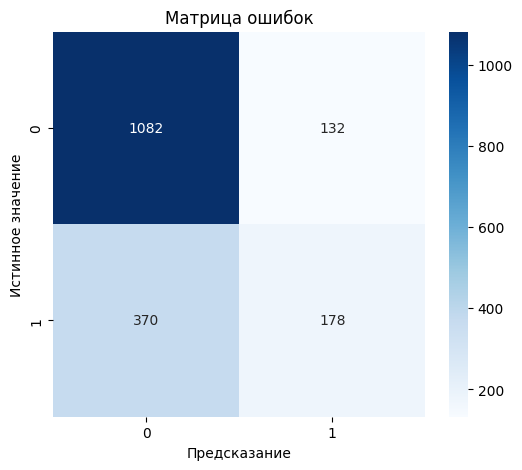

In [13]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Предсказание")
plt.ylabel("Истинное значение")
plt.title("Матрица ошибок")

plt.show()

# Итог

В ходе третьей недели была подготовлена выборка для машинного обучения, обучена модель Decision Tree и проведена оценка её качества. Полученная точность модели показывает возможность использования выбранных признаков для классификации типа контента.